# Physical scene understanding lab

This lab introduces concepts and tools for building probabilistic models of intuitive physics. It focuses on inferring physical object properties (mass, bounciness) from sequentially observed video input.

<div class="alert alert-info" markdown="1">
    <strong> Note on packages </strong>

This notebook uses its own Julia environment, described by the `Project.toml` and `Manifest.toml` sitting next to it. The next cell activates that environment and installs the pinned package versions. The first run downloads and precompiles them, which takes a few minutes; after that it is instant.

You will also need a Julia kernel registered with Jupyter, which is *separate* from this environment. If the kernel fails to start, run `using Pkg; Pkg.add("IJulia"); using IJulia; IJulia.installkernel("Julia")` in a Julia session and restart Jupyter.

</div>

In [1]:
using Pkg
Pkg.activate(@__DIR__)   # the Project.toml sitting next to this notebook
Pkg.instantiate()        # install the pinned versions (slow only the first time)

  Activating project at `~/dev/teaching/bouncing-balls-mujoco`
Precompiling packages...
   1217.4 ms  ✓ Ghostscript_jll
   2163.9 ms  ✓ Latexify
    453.0 ms  ✓ Latexify → SparseArraysExt
  16694.4 ms  ✓ Qt6ShaderTools_jll
  16702.5 ms  ✓ Qt6Svg_jll
   1436.6 ms  ✓ Qt6Declarative_jll
    449.6 ms  ✓ Qt6Wayland_jll
  7 dependencies successfully precompiled in 19 seconds. 221 already precompiled.
  31 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, InteractiveUtils, JLLWrappers, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Pkg → REPLExt, PrecompileTools, Preferences, Printf, REPL, StyledStrings, TOML, Tar, UUIDs, Unicode, Zlib_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 145 dependents of these packages may trigger further precompilation to work with the unexpected versions.


In [2]:
using MuJoCo
using Gen
using Accessors
using Distributions
using Plots

[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80]
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] 

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7](cache misses: wrong dep version loaded (1))
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a](cache misses: wrong dep version loaded (1))
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


# Visual inference using a physics-based generative model

This lab introduces a computational model that infers "physics-based representations" of scenes; in other words, the model explains visual inputs in terms of their underlying physical causes. To implement these structure-preserving representations of physical scenes, we build on the idea of a "physics engine in the mind" (introduced, in large part, by [Battaglia et al. (2013)](https://www.pnas.org/doi/pdf/10.1073/pnas.1306572110)), which refers to a general schema where the mind might use runnable mental models, akin to a physics simulator in a video game engine. One way to make this idea concrete is to embed off-the-shelf physics engines in probabilistic models.

Here, we explore an implementation that uses the probabilistic programming package `Gen` and the physics engine `MuJoCo`. We will build a generative model that defines a probability distribution over the trajectories of a ball, conditioned on the ball's bounciness and mass. We will also explore approximate Bayesian inference procedures, such as [particle filters](https://en.wikipedia.org/wiki/Particle_filter) that leverage the sequential nature of the underlying generative model.

Specifically, we will observe a sequence of the positions of a falling and bouncing ball, and based on that, infer its bounciness and mass.

## The software tools

- [Gen](https://www.gen.dev/): An open-source stack for generative modeling and probabilistic inference. (Think of Gen as what pytorch is for deep learning.)
- [MuJoCo](https://mujoco.readthedocs.io/): a fast physics engine for multi-joint dynamics with contact, widely used in robotics and machine learning. We drive it from Julia with [MuJoCo.jl](https://github.com/JamieMair/MuJoCo.jl).

The code that adapts the engine for probabilistic programming is written below. It comes to about fifty lines, and is worth reading once as an example or wrapping a deterministic "off the shelf" forward function into a probabilistic generative model.

## The physical scenario: bouncing balls

We work with a simple initial scene configuration: a single ball above the center of a table.

In MuJoCo a scene is described in [MJCF](https://mujoco.readthedocs.io/en/stable/XMLreference.html), an XML format, rather than built up with API calls. The whole scene is this:

In [3]:
const SCENE_XML = """
<mujoco>
  <option gravity="0 0 -10" timestep="0.00208333"
          integrator="implicitfast" iterations="100" tolerance="0"/>
  <worldbody>
    <geom name="table" type="box" size="1 1 0.1" pos="0 0 -0.1"/>
    <body name="ball" pos="0 0 1">
      <freejoint/>
      <geom name="ball" type="sphere" size="0.1" mass="1"
            priority="1" condim="3"/>
    </body>
  </worldbody>
</mujoco>
""";

Reading that scene, element by element:

- **`<option>`** sets global physics parameters. Gravity is $-10\ \mathrm{m/s^2}$. The timestep is $1/480\ \mathrm{s}$, and we will take 8 of them per observed frame, giving a frame duration of $1/60\ \mathrm{s}$. Setting `tolerance="0"` disables the solver's early termination so that it does the same work on every call, which keeps our simulation reproducible.
- **`<worldbody>`** is the scene root that contains objects, like our table.
- **The table** is a static box (i.e., other objects cannot move it). Its `size` is given as *half*-extents, so `1 1 0.1` is a 2m x 2m x 0.2m slab. Centering it at $z=-0.1$ puts its top surface at $z=0$. 
- **The ball** is a dynamic `<body>`, which has physical properties, like mass, and will respond to the physical forces acting upon it.

Importantly, we will be doing physical inference over properties in this scene, name the properties of the ball.

### Implementation detail (relevant for class projects using this setup)
**`priority="1"`** on the ball decides *whose* contact parameters are used when the ball touches the table. Without it, MuJoCo would combine the two geoms' parameters; with it, the ball's parameters win outright. Since the ball's contact parameters are exactly what we are going to infer, we want them in sole control of the bounce.

## Integrating Mujoco and Gen

To help scaffold probablisitic simulation around the deterministic simulator, we will define a few `structs`. The important one is `MuJoCoState`, which is a complete, self-contained snapshot of the scene: the ball's `kinematics` (where it is and how fast it is going) and its `latents` (its physical properties).

In [35]:
"The physical properties we will infer: mass and contact damping."
struct RigidBodyLatents
    data::NamedTuple
end

"Where an object is and how it is moving."
struct RigidBodyState
    position::Vector{Float64}
    orientation::Vector{Float64}
    linear_vel::Vector{Float64}
    angular_vel::Vector{Float64}
end

"A complete snapshot of the scene."
struct MuJoCoState
    kinematics::Vector{RigidBodyState}
    latents::Vector{RigidBodyLatents}
end

"The simulator itself: a compiled model, a scratch buffer, and our settings."
struct MuJoCoSim
    model::Any
    data::Any
    solref::Matrix{Float64}
    substeps::Int
    stiffness::Float64
end;

Next, we will write an interface over Mujoco that plays with with Gen's assumptions, namely having **pure** call semantics. 

Here, `physics_step` emulates a **pure function** that consistenly maps a given `MuJoCoState` to the same next `MuJoCoState`. Once we go over the inference procedure, why this is neccesary will become more apparent, however, note now that `@gen` functions are 1) re-executed frequently, and 2) often have non-trivial execution orders (i.e., not necessarily line-by-line). 

<div class="alert alert-info">
Question: What could go wrong if `physics_step` was stateful?
</div>

In [37]:
const BALL_BODY = 2   # bodies: 1 = world, 2 = ball
const BALL_GEOM = 2   # geoms:  1 = table, 2 = ball

"Build the scene and return a simulator for it."
function simple_scene(; substeps::Int = 8, stiffness::Float64 = 1e5)
    path = joinpath(tempdir(), "bouncing_ball_scene.xml")
    write(path, SCENE_XML)
    model = MuJoCo.load_model(path)
    data = MuJoCo.init_data(model)
    # MuJoCo.jl hands back `geom_solref` as a raw pointer rather than an array,
    # so we wrap it ourselves. Shape is (2, ngeom); column `i` is geom `i`.
    solref = unsafe_wrap(Array, model.geom_solref, (2, Int(model.ngeom)))
    MuJoCoSim(model, data, solref, substeps, stiffness)
end

"Read the ball's position/orientation/velocity out of MuJoCo's buffer."
read_kinematics(d) = [RigidBodyState(collect(d.qpos[1:3]), collect(d.qpos[4:7]),
                                     collect(d.qvel[1:3]), collect(d.qvel[4:6]))]

"The scene at time zero: ball at rest, 1m up."
function init_state(sim::MuJoCoSim; mass::Float64 = 1.0, damping::Float64 = 50.0)
    MuJoCo.mj_resetData(sim.model, sim.data)
    MuJoCoState(read_kinematics(sim.data),
                [RigidBodyLatents((mass = mass, damping = damping))])
end

"Push a state's physical properties into the engine."
function set_latents!(sim::MuJoCoSim, latents::Vector{RigidBodyLatents})
    l = latents[1].data
    sim.solref[1, BALL_GEOM] = -sim.stiffness
    sim.solref[2, BALL_GEOM] = -l.damping
    nothing
end

"""
	physics_step(sim, state) -> MuJoCoState

Advance the scene by one frame (1/60 s). A pure function of `state`.
"""
function physics_step(sim::MuJoCoSim, state::MuJoCoState)
    d = sim.data
    set_latents!(sim, state.latents)
    k = state.kinematics[1]
    # Write the whole state in, so nothing survives from a previous call.
    d.qpos[1:3] .= k.position
    d.qpos[4:7] .= k.orientation
    d.qvel[1:3] .= k.linear_vel
    d.qvel[4:6] .= k.angular_vel
    # The solver reuses its last answer as a starting guess. Clearing it is
    # what makes this function deterministic across particles.
    d.qacc_warmstart .= 0.0
    for _ = 1:sim.substeps
        MuJoCo.mj_step(sim.model, d)
    end
    MuJoCoState(read_kinematics(d), state.latents)
end;

That is the entire adapter. Let's build a scene and check that a ball dropped from 1m falls the way it should.

In [6]:
sim = simple_scene()
init_state_1 = init_state(sim; mass = 1.0, damping = 50.0)

MuJoCoState(RigidBodyState[RigidBodyState([0.0, 0.0, 1.0], [1.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0], [0.0, 0.0, 0.0])], RigidBodyLatents[RigidBodyLatents((mass = 1.0, damping = 50.0))])

In [7]:
# a falling ball should be at 1 - gt^2/2 before it hits anything
let s = init_state_1
    for _ = 1:20
        s = physics_step(sim, s)
    end
    t = 20 / 60
    (simulated = s.kinematics[1].position[3], analytic = 1.0 - 0.5 * 10 * t^2)
end

(simulated = 0.4409740111096788, analytic = 0.4444444444444444)

We will use the helper function `simulate_scene` to advance the simulation forward.

In [8]:
"""
	simulate_scene(sim, init_state, steps) -> [MuJoCoState]

Runs physics for `steps` steps, returning a `Vector` of `steps+1` states.
"""
function simulate_scene(sim::MuJoCoSim, init::MuJoCoState, steps::Int = 60)
    states = Vector{MuJoCoState}(undef, steps + 1)
    states[1] = init
    for i = 2:(steps+1)
        states[i] = physics_step(sim, states[i-1])
    end
    return states
end;

In [9]:
states = simulate_scene(sim, init_state_1, 60);

With some animation functions, let's take a look at the timecourse of the bouncing ball. Here, we are visualizing the height of the ball (y-axis) as a function of time (x-axis).

In [10]:
# Essentially this plots a time series of positions.
@userplot SimPlot
@recipe function f(cp::SimPlot)
    z, t = cp.args
    k = 10
    inds = (max(1, t-k):t)
    n = length(inds)
    linewidth --> range(0, 10, length = n)
    seriesalpha --> range(0, 1, length = n)
    xguide --> "time"
    yguide --> "height of ball (z)"
    ylims --> (0, 1.0)
    xlims --> (1, 60)
    label --> false
    inds, z[inds, :]
end

function get_zs(states::Vector)
    t = length(states)
    zs = Vector{Float64}(undef, t)
    for i = 1:t
        zs[i] = states[i].kinematics[1].position[3]
    end
    return zs
end

function animate_trace(trace::Vector; label = "trace")
    t = length(trace)
    zs = reshape(get_zs(trace), (t, 1))
    anim = @animate for i = 2:t
        simplot(zs, i, label = label)
    end
end;

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
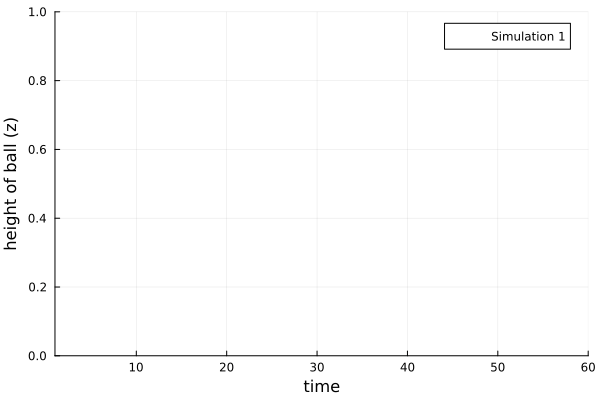

In [11]:
anim = animate_trace(states; label = "Simulation 1");
gif(anim, fps = 24)

Now compare that scene to the one below: what *jumps* out?

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
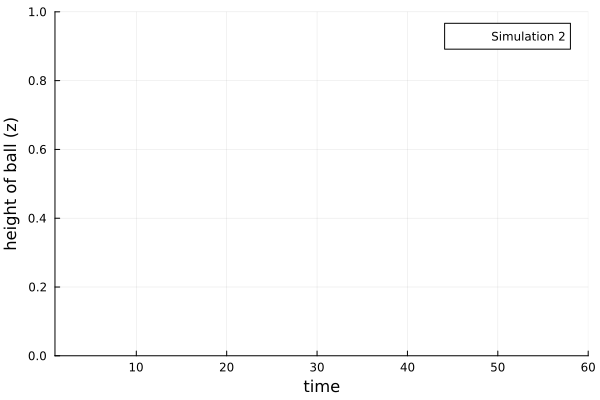

In [12]:
# same ball, but with more contact damping: a deader bounce
init_state_2 = init_state(sim; mass = 1.0, damping = 150.0)
states2 = simulate_scene(sim, init_state_2, 60)
anim2 = animate_trace(states2; label = "Simulation 2")
gif(anim2, fps = 24)

We clearly see a difference in their trajectories --- the different heights each ball reaches. But it is also possible that we see something higher-level: *what has caused* these two different trajectories, namely the different physical properties of each ball. You can almost *hear* the distinct sound each collision would make on the table.

Our goal is to implement a psychologically plausible algorithm that can model such human perception of physical properties. We will do so in two parts:

1. Specify a generative model: the conditional distributions over how objects move and appear.
2. Implement an inference algorithm that updates the states and latents of objects given a sequence of observations.

## Part 1: The physical generative model

The generative model takes as input the initial scene configuration (a ball positioned above a stable table), and defines conditional distributions over how objects move and appear, producing a sequence of predictions about the object state across time.

The following diagram illustrates these conditional relationships:

<center>
<img src="https://raw.githubusercontent.com/CNCLgithub/AlgorithmsOfVisionCCN2025/refs/heads/bouncing_ball/physics_chain.svg" style="width: 50%; height: auto;">     
</center>


$$
Pr(\vec{S}, \vec{X}) = Pr(S_0) \prod\limits_{t=1}^{T} Pr(X_t \mid S_t) \cdot Pr(S_t \mid S_{t-1})
$$

This factorizes into three conditional distributions, each implemented as a `Gen` generative function:

1. `prior`: $Pr(S_0)$ samples new latents from a prior distribution: here, mass and contact damping.
2. `observe`: $Pr(X_t \mid S_t)$ generates noisy observations of object position in $\mathcal{R}^3$.
3. `kernel`: $Pr(S_t \mid S_{t-1})$ steps the simulation forward.

### The prior over latent variables, $Pr(S_0)$

The `prior` defines a distribution over what the physical properties of an object *should* be: here mass and contact damping. We manipulate the values with a small helper.

In [13]:
"""
	update_latents(latents, mass, damping) -> RigidBodyLatents

A helper to update the latent variables we wish to make inferences about.
"""
function update_latents(ls::RigidBodyLatents, mass::Float64, damping::Float64)
    RigidBodyLatents(setproperties(ls.data; mass = mass, damping = damping))
end;

In [14]:
"""
	prior(template) -> RigidBodyLatents

Samples mass and contact damping given a template set of other latents.
"""
@gen function prior(ls::RigidBodyLatents)
    mass ~ gamma(1.2, 10.)
    damping ~ uniform(0, 300)
    new_latents = update_latents(ls, mass, damping)
    return new_latents
end;

Notice that `prior` is a special kind of function: a generative function (indicated by the `@gen` macro) whose evaluations are stochastic, giving different values each time it is run.

Mass is [Gamma](https://en.wikipedia.org/wiki/Gamma_distribution) distributed, and damping is uniform on $[0, 300]$, which spans a perfectly elastic ball at one end and a nearly dead one at the other. (Here is a helpful [tool](https://distribution-explorer.github.io/) for exploring probability distributions.)

Run the cell below a few times and watch the values change.

In [15]:
prior(RigidBodyLatents((mass = 0.5, damping = 50.0)))

RigidBodyLatents((mass = 2.703700487790829, damping = 7.179999713226836))

### The likelihood: how well does a state explain an observation, $Pr(X_t \mid S_t)$

In [16]:
@doc raw"""
	observe(state) -> XYZ

Defines a conditional distribution over the object's 3D position with ``\sigma=0.1``
"""
@gen function observe(state::RigidBodyState)
    position ~ broadcasted_normal(state.position, 0.1)
    return position
end;

#### A note about the observation space

You might be thinking that this is a contrived observation space --- and we agree! The `observe` generative function can readily incorporate pixel-based (or other sensor computable) observation spaces. However, using them in this demo would incur unnecessary technical complications (e.g. the need for GPUs).

For examples from real projects that do use sensor-computable observation spaces, see [Woven](https://github.com/CNCLgithub/Woven) (Bi et al., 2025, *Nature Communications*), [GranularScenes](https://github.com/CNCLgithub/GranularScenes) (Belledonne & Yildirim), and [ThreeDP3](https://github.com/probcomp/ThreeDP3) (Gothoskar et al., 2021, *NeurIPS*).

### The kernel: how objects move, $Pr(S_t \mid S_{t-1})$

In [17]:
@doc raw"""
	kernel(t, prev_state, sim) -> next_state

Advances the physical scene by one timestep and samples observations for that new state.
"""
@gen function kernel(t::Int, prev_state::MuJoCoState, sim::MuJoCoSim)
    next_state::MuJoCoState = physics_step(sim, prev_state)
    positions ~ Gen.Map(observe)(next_state.kinematics)
    return next_state
end;

Notice that the kernel calls the physics engine to step the simulation one timestep forward. This is what implements temporal dynamics in the generative model.

### The full generative model

In [18]:
@doc raw"""
	model(T, sim, template) -> [MuJoCoState]

Samples an initial set of latents from the `prior` and then simulates for `T` steps, using `kernel`.
"""
@gen function model(T::Int, sim::MuJoCoSim, template::MuJoCoState)
    latents ~ Gen.Map(prior)(template.latents)
    init = Accessors.setproperties(template; latents = latents)
    states ~ Gen.Unfold(kernel)(T, init, sim)
    return states
end;

In [19]:
# arguments for `model`
gargs = (60,               # number of steps (total duration 1s)
         sim,
         init_state_1);

We use `Gen.generate()` to run the model forward. It takes a generative function and its arguments, and returns a trace: a record of all the stochastic decisions made during the call.

In [20]:
trace, _ = Gen.generate(model, gargs);

In [21]:
function get_zs(trace::Gen.Trace)
    t, _... = get_args(trace)
    states = get_retval(trace)
    zs = Vector{Float64}(undef, t)
    for i = 1:t
        zs[i] = states[i].kinematics[1].position[3]
    end
    return zs
end

function animate_trace(trace::Gen.Trace; label = "trace")
    t = first(get_args(trace))
    zs = reshape(get_zs(trace), (t, 1))
    anim = @animate for i = 2:t
        simplot(zs, i, label = label)
    end
end

animate_trace (generic function with 2 methods)

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
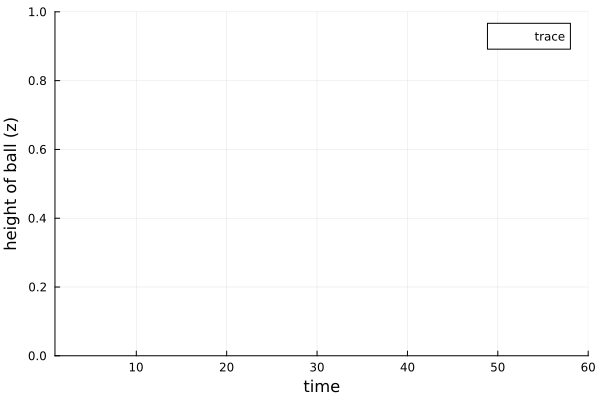

In [22]:
gif(animate_trace(trace), fps = 24)

By repeatedly running `generate`, we draw different samples from the generative model. Here we visualize several, and see how each leads to a different timecourse.

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
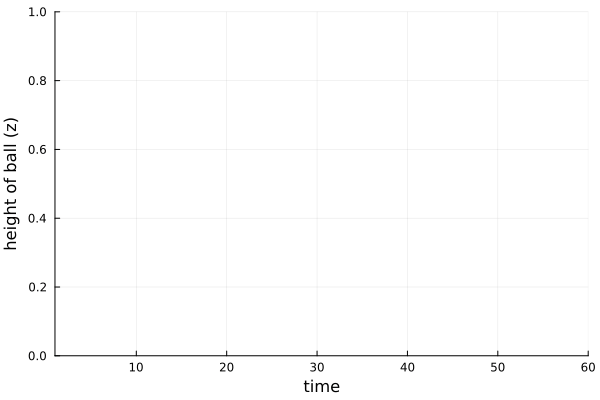

In [23]:
traces = [Gen.simulate(model, gargs) for _ = 1:7];

function animate_traces(traces::Vector{<:Gen.Trace})
    zzs = reduce(hcat, map(get_zs, traces))
    t = size(zzs, 1)
    anim = @animate for i = 2:t
        simplot(zzs, i)
    end
end

gif(animate_traces(traces), fps = 24)

## Part 2: Inference over dynamic scenes, $Pr(\vec{S} \mid \vec{X})$

How can we infer the physical latents of the scene given a sequence of observations? By [Bayes' theorem](https://en.wikipedia.org/wiki/Bayes'_theorem) we condition the generative model on observations to get the posterior.

Let's take our first simulation and extract noisy positions. These serve as our observations $\vec{X}$. Note the ground truth latents: mass 1.0 and damping 50.0.

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
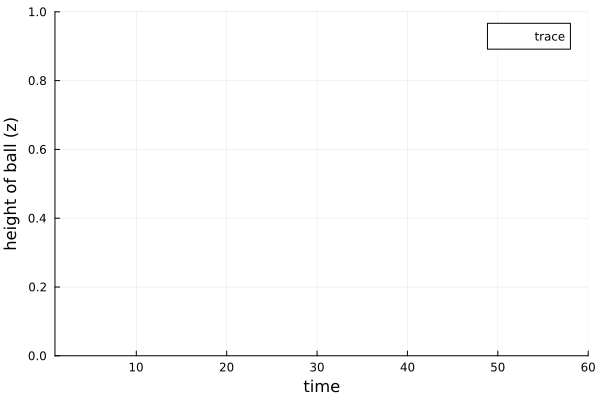

In [24]:
gt_latents = choicemap(
    (:latents => 1 => :damping, 50.0),
    (:latents => 1 => :mass, 1.0)
)
gt = first(generate(model, gargs, gt_latents));
gt_choices = get_choices(gt)

t = gargs[1]

# one set of observations per time step
# (notice that these do not contain the gt latents)
observations = Vector{Gen.ChoiceMap}(undef, t)
for i = 1:t
    cm = choicemap()
    addr = :states => i => :positions
    set_submap!(cm, addr, get_submap(gt_choices, addr))
    observations[i] = cm
end

gif(animate_trace(gt), fps = 24)

## The inference procedure: a particle filter

A standard workhorse in Bayesian inference is [Metropolis-Hastings MCMC](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm), but it is not desirable here, as it requires all observations at once rather than sequentially.

A far more natural (but by no means perfect) algorithm is the [particle filter](https://www.stats.ox.ac.uk/~doucet/smc_resources.html), which excels at posteriors that factorize sequentially. Each particle is an independent trace of the generative model, conditioned on the observations so far. Together the particles form a non-parametric approximation of the posterior.

At each time step the filter has three steps:

1. **Update**: each particle samples the next state via `kernel`, weighted by both the transition prior and the likelihood of the new observation.
2. **Resample**: particles are drawn, with replacement, from a multinomial based on the normalized log-scores.
3. **Rejuvenation**: each surviving particle receives probabilistic adjustments to its latents via a `proposal`, accepted or rejected by the Metropolis-Hastings criterion.

### The proposal function

This takes a trace of the model and draws mass and damping around the current guess, using a truncated normal to prevent physically impossible values (e.g. negative mass) and values outside the stable range for damping.

In [25]:
"""A truncated normal distribution"""
struct TruncNorm <: Gen.Distribution{Float64} end

const trunc_norm = TruncNorm()

function Gen.random(::TruncNorm, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.rand(d)
end;

function Gen.logpdf(::TruncNorm, x::Float64, mu::U, noise::T, low::T, high::T) where {U<:Real,T<:Real}
    d = Distributions.Truncated(Distributions.Normal(mu, noise), low, high)
    return Distributions.logpdf(d, x)
end;

In [26]:
"""
This proposal function implements a random walk for mass and contact damping.
"""
@gen function proposal(tr::Gen.Trace)
    # get previous values from `tr`
    choices = get_choices(tr)
    prev_mass = choices[:latents => 1 => :mass]
    prev_damping = choices[:latents => 1 => :damping]

    # sample new values conditioned on the old ones
    mass = {:latents => 1 => :mass} ~ trunc_norm(prev_mass, 1.0, 0., Inf)
    damping = {:latents => 1 => :damping} ~ trunc_norm(prev_damping, 30., 0., 300.)

    return (mass, damping)
end;

Below we implement a standard particle filter with rejuvenation moves.

In [27]:
"""
    inference_procedure

Performs particle filter inference with rejuvenation.
"""
function inference_procedure(gm_args::Tuple,
                             obs::Vector{Gen.ChoiceMap},
                             particles::Int = 20,
                             rejuv_moves::Int = 2)
    get_args(t) = (t, gm_args[2:3]...)

    # initialize particle filter
    state = Gen.initialize_particle_filter(model, get_args(0), EmptyChoiceMap(), particles)
    argdiffs = (UnknownChange(), NoChange(), NoChange())

    for (t, o) = enumerate(obs)
        # STEP 1: update
        Gen.particle_filter_step!(state, get_args(t), argdiffs, o)
        # STEP 2: resample
        Gen.maybe_resample!(state, ess_threshold = particles / 2)
        # STEP 3: rejuvenation
        for i = 1:particles, s = 1:rejuv_moves
            state.traces[i], _ = mh(state.traces[i], proposal, ())
        end
    end

    return Gen.sample_unweighted_traces(state, particles)
end;

### Inference results

Now let's run the particle filter with 20 particles (and 2 rejuvenation moves per particle per step) across each of the 60 observations.

In [28]:
result = inference_procedure(gargs, observations);

To visualize inference results, let's animate each particle after conditioning on all observations.

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
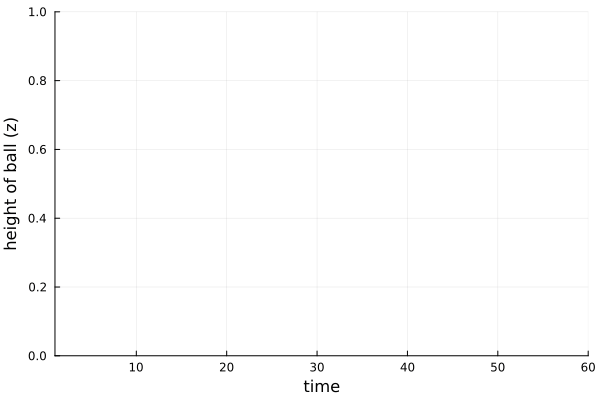

In [29]:
gif(animate_traces(result), fps = 24)

Recall the inference task: infer the contact damping and mass of the object given a series of noisy position observations. Let's look at the marginal of each latent.

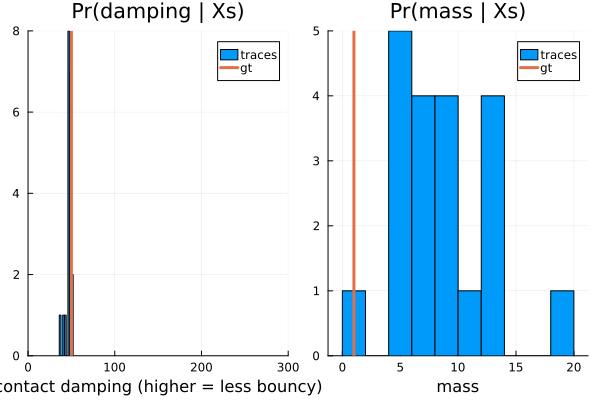

In [30]:
function get_latents(traces::Vector{<:Gen.Trace})
    n = length(traces)
    mass = Vector{Float64}(undef, n)
    damping = Vector{Float64}(undef, n)
    for i = 1:n
        mass[i] = traces[i][:latents => 1 => :mass]
        damping[i] = traces[i][:latents => 1 => :damping]
    end
    (mass, damping)
end

function plot_latents(traces::Vector{<:Gen.Trace}; gt_mass = 1.0, gt_damping = 50.0)
    mass, damping = get_latents(traces)
    damp_plt = histogram(
        damping, title = "Pr(damping | Xs)",
        xlabel = "contact damping (higher = less bouncy)", label = "traces",
        xlims = (0., 300.), bins = 10
    )
    vline!(damp_plt, [gt_damping], label = "gt", linewidth = 3)
    mass_plt = histogram(
        mass, title = "Pr(mass | Xs)",
        xlabel = "mass", bins = 10, label = "traces"
    )
    vline!(mass_plt, [gt_mass], label = "gt", linewidth = 3)
    return plot(damp_plt, mass_plt)
end

plot_latents(result)

Note how damping lands close to the ground truth of 50, whereas mass is spread over essentially the whole prior (the ground truth was 1.0 --- but so would any other value have been).

Why is this the case? (Discuss amongst yourselves.)

The short version: every observation is a noisy 3D position, and nothing about where the ball is at any moment depends on how heavy it is. The likelihood is flat in mass, so the posterior over mass is just the prior. Contrast this with a scene containing a *collision between two objects*, where momentum transfer would make the mass ratio observable --- a natural extension of this notebook.

## Comparing two scenes

We inferred a posterior over physical latents for the first scene; let's now do the same for the second, the one with damping 150.

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
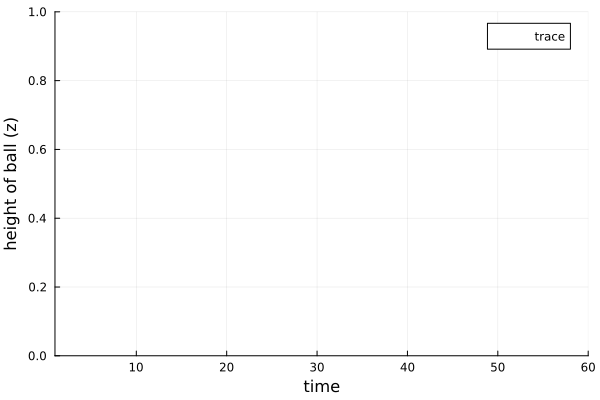

In [31]:
gt_latents2 = choicemap(
    (:latents => 1 => :damping, 150.0),
    (:latents => 1 => :mass, 1.0)
)
gt2 = first(generate(model, gargs, gt_latents2));
gt_choices2 = get_choices(gt2)

observations2 = Vector{Gen.ChoiceMap}(undef, t)
for i = 1:t
    cm = choicemap()
    addr = :states => i => :positions
    set_submap!(cm, addr, get_submap(gt_choices2, addr))
    observations2[i] = cm
end

gif(animate_trace(gt2), fps = 24)

In [32]:
result2 = inference_procedure(gargs, observations2);

[ Info: Saved animation to /home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif


Plots.AnimatedGif("/home/mario/dev/teaching/bouncing-balls-mujoco/tmp.gif")
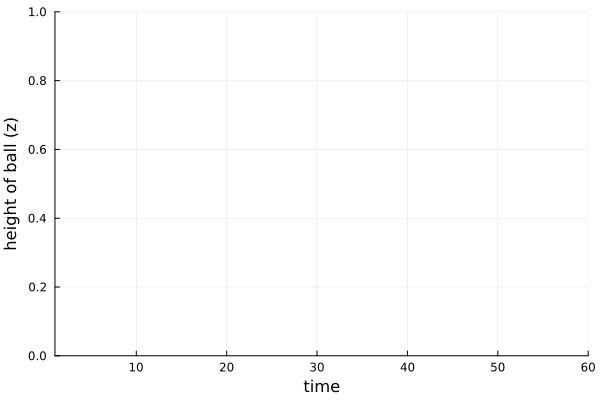

In [33]:
gif(animate_traces(result2), fps = 24)

Comparing the two posteriors, the model is confident that the ball in the first simulation is bouncier (has lower contact damping) than the ball in the second.

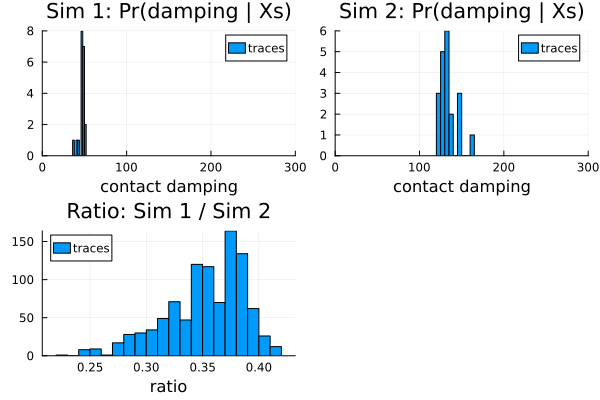

In [34]:
function bootstrap_ratio(latent1, latent2, n = 1000)
    samples = Vector{Float64}(undef, n)
    for i = 1:n
        samples[i] = rand(latent1) / rand(latent2)
    end
    return samples
end

function compare_latents(sim1::Vector{<:Gen.Trace}, sim2::Vector{<:Gen.Trace})
    _, damping1 = get_latents(sim1)
    _, damping2 = get_latents(sim2)
    ratio = bootstrap_ratio(damping1, damping2)

    plt1 = histogram(
        damping1, title = "Sim 1: Pr(damping | Xs)",
        xlabel = "contact damping", label = "traces",
        xlims = (0., 300.), bins = 10
    )
    plt2 = histogram(
        damping2, title = "Sim 2: Pr(damping | Xs)",
        xlabel = "contact damping", label = "traces",
        xlims = (0., 300.), bins = 10
    )
    ratio_plt = histogram(
        ratio, title = "Ratio: Sim 1 / Sim 2",
        xlabel = "ratio", label = "traces", bins = 20
    )
    return plot(plt1, plt2, ratio_plt)
end

compare_latents(result, result2)

## Summary and future reading

You've coded a basic model that infers structure-preserving representations using probabilistic programming, with MuJoCo as the forward model. You can continue your learning through the following resources.

* We encourage you to read the [Woven paper (Bi et al., 2025)](https://www.nature.com/articles/s41467-025-61458-x) and explore its [codebase](https://github.com/CNCLgithub/Woven).
* Explore the official [Gen tutorials](https://www.gen.dev/tutorials/).
* Explore lab sections of the [Algorithms of the Mind](https://github.com/CNCLgithub/Algorithms-of-the-Mind/tree/main/labs) course.
* The [MuJoCo documentation](https://mujoco.readthedocs.io/) on [contact modeling](https://mujoco.readthedocs.io/en/stable/computation/index.html#contact) and [solver parameters](https://mujoco.readthedocs.io/en/stable/modeling.html#solver-parameters), if you want to understand the soft-contact model we configured above.